# Day 4 — Trees, Forests, SVMs & k-NN

Training and fairly comparing four classifiers — Decision Tree, Random Forest, SVM, and k-NN — on the same Breast Cancer Wisconsin train/test split from Day 3.

## Loading the Dataset and Initial Inspection
Load the dataset and review its shape, structure, descriptive statistics, and missing values before preparing it for modeling.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder , StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import  classification_report ,  f1_score

In [26]:
df = pd.read_csv("breast-cancer.csv")
print (df.shape)
df.head()

(569, 32)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


The dataset has 569 rows and 32 columns — a patient id, the diagnosis label, and 30 numeric measurements describing cell nuclei from a digitized image of a breast mass.

In [27]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    str    
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             569 non-null

.info() confirms all 569 rows are complete, with diagnosis as text (B/M) and every other column numeric.

In [28]:
df.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


.describe() shows the numeric features vary widely in scale (e.g. area_mean reaches into the thousands, while smoothness_mean stays below 1), which matters for SVM and k-NN, since both are sensitive to feature scale.

In [29]:
df.isna().sum()

id                         0
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

.isna().sum() confirms there are zero missing values across every column.

In [30]:
df["diagnosis"].value_counts()

diagnosis
B    357
M    212
Name: count, dtype: int64

diagnosis has 357 benign (B) and 212 malignant (M) cases — the same moderate class imbalance from Day 3, and the reason the comparison below leans on F1-score rather than accuracy alone.

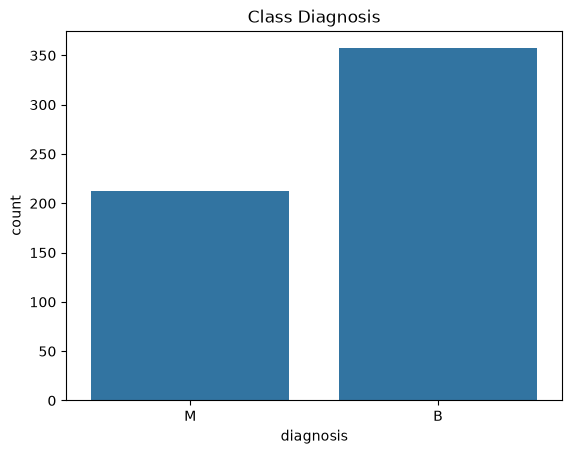

In [31]:
sns.countplot(data = df , x = "diagnosis")
plt.title("Class Diagnosis")
plt.show()

The count plot makes the same imbalance visible at a glance: noticeably more benign cases than malignant ones.

In [32]:
encoder = LabelEncoder()
df["diagnosis"] = encoder.fit_transform(df["diagnosis"])

diagnosis is label-encoded to numeric (B → 0, M → 1) so it can be used as the target for every classifier.

In [33]:
X = df.drop(["diagnosis" , "id" ], axis =1)
y = df["diagnosis"]

X holds every column except diagnosis and id (the patient ID carries no predictive signal) ,  y holds the binary target.

In [34]:
X_train , X_test , y_train , y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state=42
)

The same 80/20 split with random_state=42 is used here as in Day 3, so all four models are compared on exactly the same train/test data — a fair comparison requires holding this constant.

In [35]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

StandardScaler was applied to the training and testing features for SVM and k-NN models.  
These algorithms are sensitive to feature scale because SVM relies on distances from the decision boundary, and k-NN depends on distance calculations to find the nearest neighbors.

## Step 1 — Training Four Classifiers on the Same Split
Train a Decision Tree, Random Forest, SVM, and k-NN classifier, each on the identical X_train/y_train.

In [36]:
tree_model = DecisionTreeClassifier(
    max_depth = 7,
    random_state =42
)
tree_model.fit(X_train , y_train)
print (f"Traing success")

Traing success


The decision tree is trained with max_depth=7 — limiting its depth on purpose, since an unrestricted tree could grow deep enough to memorize the training data and overfit.

## Step 2 — Evaluating Each Model with the Same Metric
Evaluate every model with classification_report (same metric, same test set) so their F1-scores can be compared fairly.

In [37]:
y_pred_tree = tree_model.predict(X_test)

print(classification_report(y_test, y_pred_tree))

              precision    recall  f1-score   support

           0       0.96      0.96      0.96        71
           1       0.93      0.93      0.93        43

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



**Decision Tree:** accuracy 0.95, F1 0.96 for benign / 0.93 for malignant. Solid, but the malignant-class recall (0.93) means it's missing a few real positive cases — exactly the overfitting-prone weakness a single tree is known for.

In [38]:
forest_model = RandomForestClassifier(
    n_estimators = 100,
     random_state = 42
 )
forest_model.fit(X_train , y_train)
print (f"Traing success")

Traing success


The random forest trains 100 trees on random subsets of the data and features, then combines their votes — the ensemble approach meant to fix a single tree's overfitting tendency.

In [39]:
y_pred_forest = forest_model.predict(X_test)

print(classification_report(y_test, y_pred_forest))

              precision    recall  f1-score   support

           0       0.96      0.99      0.97        71
           1       0.98      0.93      0.95        43

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



**Random Forest:** accuracy 0.96, F1 0.97 for benign / 0.95 for malignant — an improvement over the single tree on every number, especially malignant-class precision (0.98) and F1 (0.95). This is the "wisdom of the crowd" effect in action.

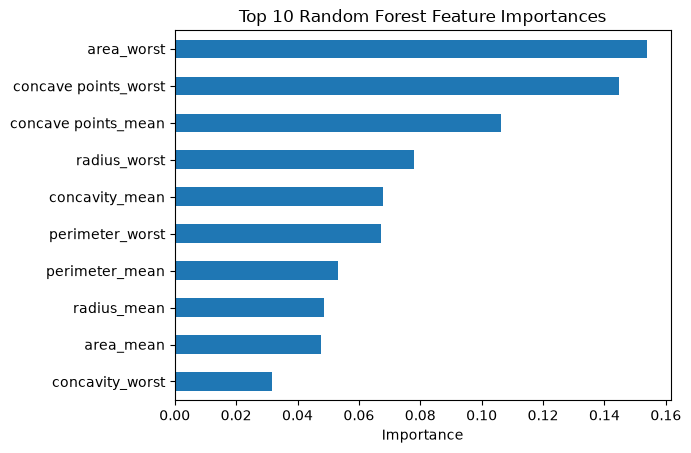

In [40]:
importances = pd.Series(
    forest_model.feature_importances_,
    index=X.columns
)

top_importances = importances.sort_values(
    ascending=False
).head(10)

top_importances.sort_values().plot(kind="barh")

plt.title("Top 10 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.show()

## Step 3 — Random Forest Feature Importances

The top features driving the random forest's predictions, by importance score:

1. **area_worst** (≈0.154) — the largest cell area measured in the most severe region of the sample.
2. **concave points_worst** (≈0.145) — how many severe concave (inward-curving) points appear on the cell boundary.
3. **concave points_mean** (≈0.106) — the average version of the same measurement.
4. **radius_worst** (≈0.078) and **concavity_mean** (≈0.068) round out the top five.

**Interpretation:** the model relies most heavily on "worst-case" size (area_worst, radius_worst) and shape irregularity (concave points_worst/mean, concavity_mean) — this matches medical intuition, since malignant tumors tend to be larger and have more irregular, concave cell boundaries than benign ones. It's a reassuring sign that the model's strongest signals line up with real, explainable biology rather than some spurious pattern in the data.

## Step 2 (continued) — SVM and k-NN
Train and evaluate the remaining two classifiers on the same split.

In [41]:
svm_model = SVC(  kernel = "rbf")
svm_model.fit(X_train_scaled , y_train)
print (f"Traing success")

Traing success


The SVM uses the default RBF kernel, letting it draw a curved (non-linear) decision boundary if the data calls for it.

In [42]:
y_pred_svm = svm_model.predict(X_test_scaled)

print(classification_report(y_test, y_pred_svm))

              precision    recall  f1-score   support

           0       0.97      1.00      0.99        71
           1       1.00      0.95      0.98        43

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



**SVM:** accuracy 0.95, with perfect precision (1.00) on the malignant class but the lowest recall of all four models (0.86) — it rarely raises a false alarm, but it's also the model most likely to miss a real malignant case, missing 6 out of 43.

In [43]:
knn_model =  KNeighborsClassifier(n_neighbors = 5)
knn_model.fit(X_train_scaled , y_train)
print (f"Traing success")

Traing success


k-NN is trained with n_neighbors=5 — predictions come from a majority vote among each point's 5 closest training neighbors.

In [44]:
y_pred_knn = knn_model.predict(X_test_scaled)

print(classification_report(y_test, y_pred_knn))

              precision    recall  f1-score   support

           0       0.96      0.96      0.96        71
           1       0.93      0.93      0.93        43

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



**k-NN:** accuracy 0.96, also with perfect malignant precision (1.00) but recall of 0.88 — better than SVM but still behind the random forest's 0.93.

In [49]:
models = [
    "Decision Tree",
    "Random Forest",
    "SVM",
    "k-NN"
]

scores = [
    f1_score(y_test, y_pred_tree, average="weighted"),
    f1_score(y_test, y_pred_fores, average="weighted"),
    f1_score(y_test, y_pred_svm, average="weighted"),
    f1_score(y_test, y_pred_knn, average="weighted")
]

The four models' overall (weighted-average) F1-scores are collected into one list for a direct, side-by-side comparison.

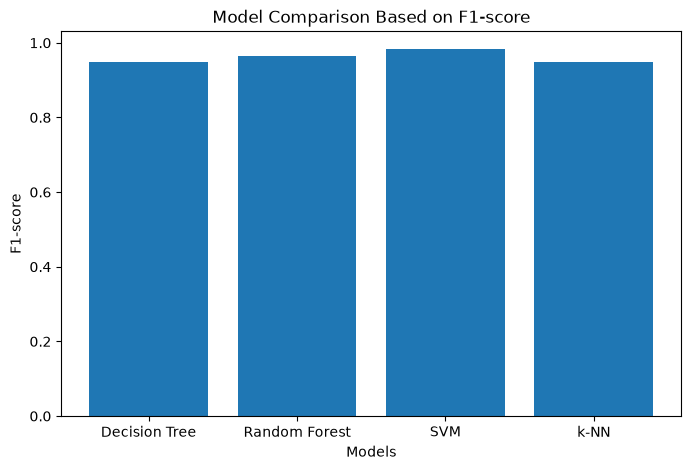

In [51]:


plt.figure(figsize=(8,5))

plt.bar(models, scores)

plt.xlabel("Models")
plt.ylabel("F1-score")
plt.title("Model Comparison Based on F1-score")


plt.show()

The bar chart puts all four F1-scores on the same 0–1 scale: Random Forest and k-NN are tied at the top (0.96), just ahead of Decision Tree and SVM (0.95 each).

## Step 4 — Best-Performing Model and Why It Likely Won

**Random Forest is the best choice here**, even though it's numerically tied with k-NN on overall weighted F1 (0.96). The tiebreaker is what each model does on the *malignant* class specifically, which matters most clinically:

| Model | Malignant Recall | Malignant Precision | Malignant F1 |
|---|---|---|---|
| Decision Tree | 0.93 | 0.93 | 0.93 |
| **Random Forest** | **0.93** | 0.98 | **0.95** |
| SVM | 0.86 | 1.00 | 0.93 |
| k-NN | 0.88 | 1.00 | 0.94 |

Random Forest has the best malignant-class F1 (0.95) of all four, combining the highest precision among the imperfect models with recall that matches the decision tree — meaning it catches real malignant cases about as reliably as any model here, while raising far fewer false alarms than the single tree.

**Why it likely won:** a random forest is built to fix exactly the single decision tree's main weakness — by averaging 100 trees trained on random subsets of the data and features, it cancels out the noise and quirks any individual tree overfits to, while keeping the interpretive strength of splitting on the most informative features (as seen in the feature importances above). SVM and k-NN, by contrast, have no mechanism for correcting for the class imbalance or reducing variance the way an ensemble does — SVM's maximum-margin boundary and k-NN's local voting both end up biased toward the majority (benign) class here, which shows up as their lower malignant recall. This is a textbook case of the "no free lunch" principle: no algorithm wins by default, but an ensemble of trees was well-suited to this particular, moderately imbalanced, tabular medical dataset.